In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("D:/HousePricing/data/kc_house_data.csv")
df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [3]:
df.describe(include="all")

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580302e+09,NaN,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [5]:
raw_skew = df["price"].skew()
raw_kurt = df["price"].kurt()

print(f"Raw price - Skewness : {raw_skew:.2f} and kurtosis: {raw_kurt:.2f}")

Raw price - Skewness : 4.02 and kurtosis: 34.59


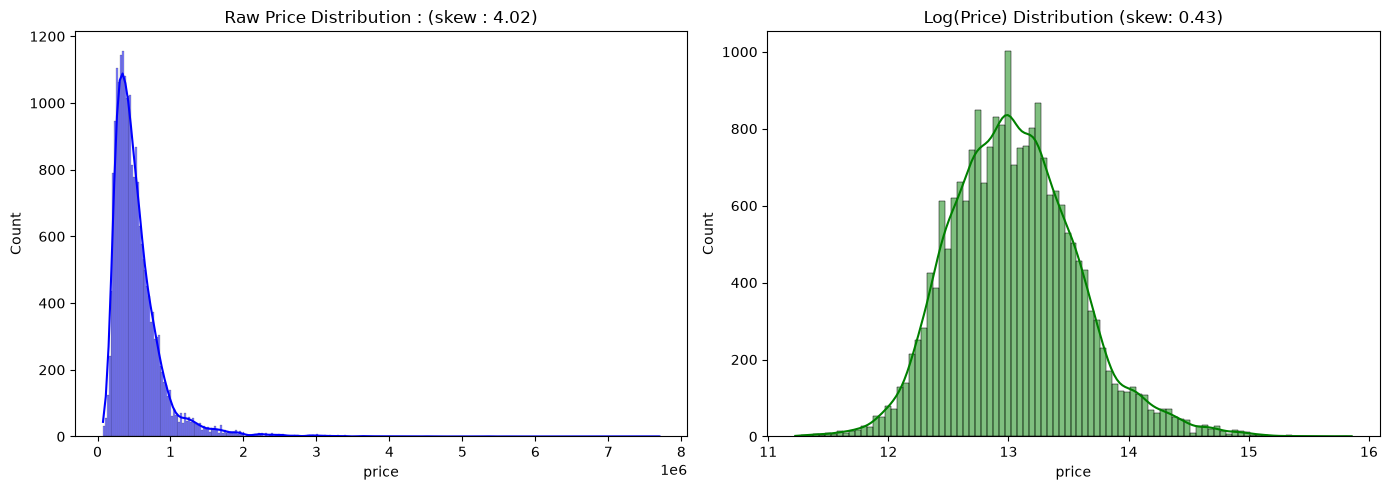

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], kde=True, ax=axes[0], color="blue")
axes[0].set_title(f"Raw Price Distribution : (skew : {raw_skew:.2f})")

log_price = np.log(df["price"])

sns.histplot(log_price, kde=True, ax=axes[1], color="green")
axes[1].set_title(f"Log(Price) Distribution (skew: {log_price.skew():.2f})")

plt.tight_layout()
plt.show()

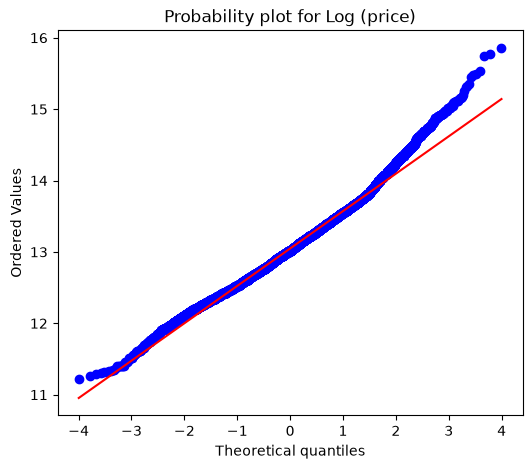

In [7]:
fig, axes = plt.subplots(figsize=(6,5))

stats.probplot(log_price, dist="norm", plot=axes)
axes.set_title("Probability plot for Log (price)")
plt.show()

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

rows = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df[col] < lower) | (df[col] > upper)
    
    rows.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "median": df[col].quantile(0.50),
        "skewness": df[col].skew(),
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_pct": mask.mean() * 100
        })
    
outlier_report = pd.DataFrame(rows)
outlier_report.sort_values(
    "outlier_pct",
    ascending=False
)

,column,min,max,median,skewness,lower_bound,upper_bound,outlier_count,outlier_pct
5,sqft_lot,5.200000e+02,1.651359e+06,7.618000e+03,13.060019,-3.432000e+03,1.916000e+04,2425,11.220099
19,sqft_lot15,6.510000e+02,8.712000e+05,7.620000e+03,9.506743,-2.374500e+03,1.755750e+04,2194,10.151298
8,view,0.000000e+00,4.000000e+00,0.000000e+00,3.395750,0.000000e+00,0.000000e+00,2124,9.827419
10,grade,1.000000e+00,1.300000e+01,7.000000e+00,0.771103,5.500000e+00,9.500000e+00,1911,8.841901
1,price,7.500000e+04,7.700000e+06,4.500000e+05,4.024069,-1.626250e+05,1.129575e+06,1146,5.302364
14,yr_renovated,0.000000e+00,2.015000e+03,0.000000e+00,4.549493,0.000000e+00,0.000000e+00,914,4.228936
11,sqft_above,2.900000e+02,9.410000e+03,1.560000e+03,1.446664,-3.400000e+02,3.740000e+03,611,2.827002
4,sqft_living,2.900000e+02,1.354000e+04,1.910000e+03,1.471555,-2.575000e+02,4.234500e+03,572,2.646555
3,bathrooms,0.000000e+00,8.000000e+00,2.250000e+00,0.511108,6.250000e-01,3.625000e+00,571,2.641928
2,bedrooms,0.000000e+00,3.300000e+01,3.000000e+00,1.974300,1.500000e+00,5.500000e+00,546,2.526257


In [9]:
df[df["bedrooms"] >= 10]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
8757,1773100755,20140821T000000,520000.0,11,3.00,3000,4960,2.0,0,0,...,7,2400,600,1918,1999,98106,47.5560,-122.363,1420,4960
13314,627300145,20140814T000000,1148000.0,10,5.25,4590,10920,1.0,0,2,...,9,2500,2090,2008,0,98004,47.5861,-122.113,2730,10400
15161,5566100170,20141029T000000,650000.0,10,2.00,3610,11914,2.0,0,0,...,7,3010,600,1958,0,98006,47.5705,-122.175,2040,11914
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700
19254,8812401450,20141229T000000,660000.0,10,3.00,2920,3745,2.0,0,0,...,7,1860,1060,1913,0,98105,47.6635,-122.320,1810,3745


In [10]:
df.loc[df["bedrooms"] == 33, "bedrooms"] = 3

In [11]:
mode = df["bedrooms"].mode()
print(type(mode.values))

<class 'numpy.ndarray'>


In [12]:
df[df["bedrooms"] <= 0]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,20140612T000000,1095000.0,0,0.00,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
3119,3918400017,20150205T000000,380000.0,0,0.00,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
3467,1453602309,20140805T000000,288000.0,0,1.50,1430,1650,3.0,0,0,...,7,1430,0,1999,0,98125,47.7222,-122.290,1430,1650
4868,6896300380,20141002T000000,228000.0,0,1.00,390,5900,1.0,0,0,...,4,390,0,1953,0,98118,47.5260,-122.261,2170,6000
6994,2954400190,20140624T000000,1295650.0,0,0.00,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
8477,2569500210,20141117T000000,339950.0,0,2.50,2290,8319,2.0,0,0,...,8,2290,0,1985,0,98042,47.3473,-122.151,2500,8751
8484,2310060040,20140925T000000,240000.0,0,2.50,1810,5669,2.0,0,0,...,7,1810,0,2003,0,98038,47.3493,-122.053,1810,5685
9773,3374500520,20150429T000000,355000.0,0,0.00,2460,8049,2.0,0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050
9854,7849202190,20141223T000000,235000.0,0,0.00,1470,4800,2.0,0,0,...,7,1470,0,1996,0,98065,47.5265,-121.828,1060,7200
12653,7849202299,20150218T000000,320000.0,0,2.50,1490,7111,2.0,0,0,...,7,1490,0,1999,0,98065,47.5261,-121.826,1500,4675


In [13]:
df = df[df["bathrooms"] > 0].copy()

In [14]:
df[df["id"] == 6306400140]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


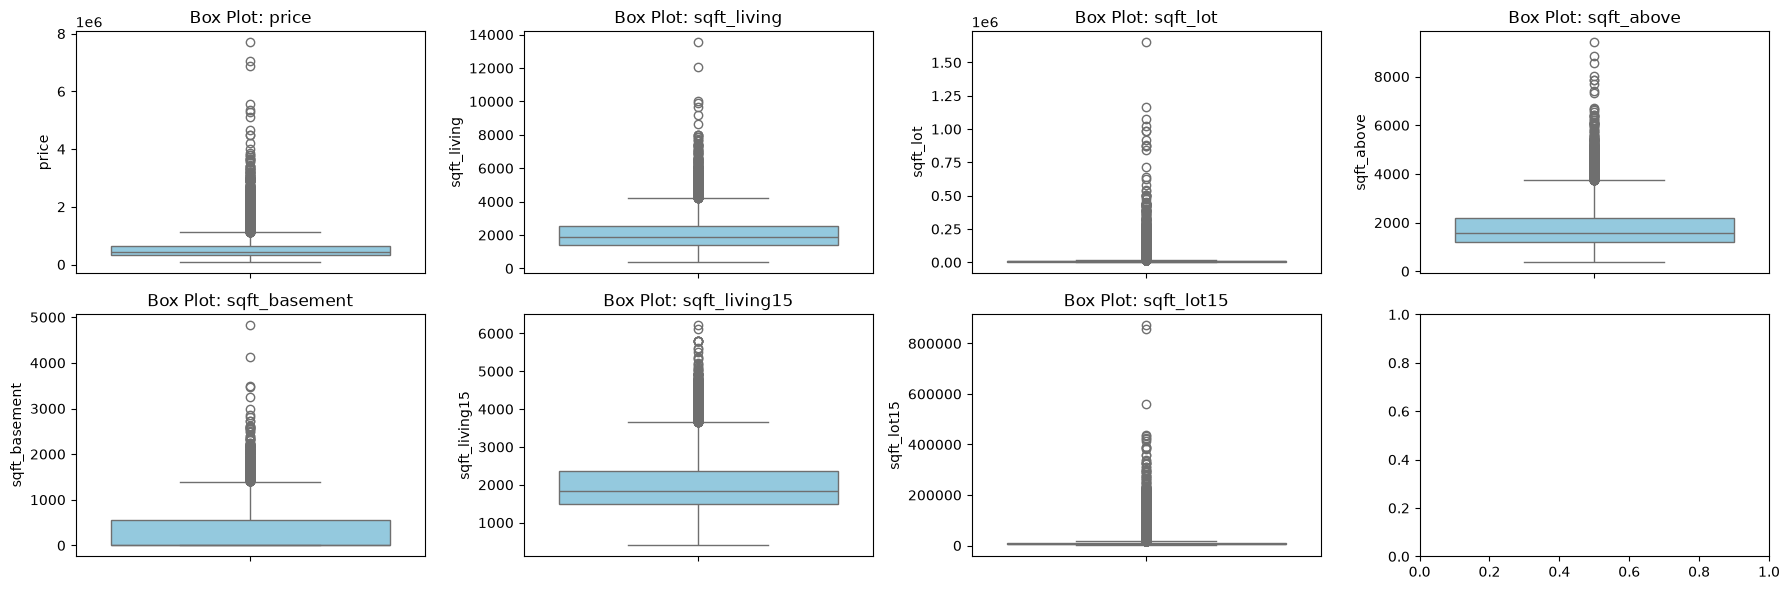

In [15]:
continuous_cols = ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Box Plot: {col}")
    
# axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

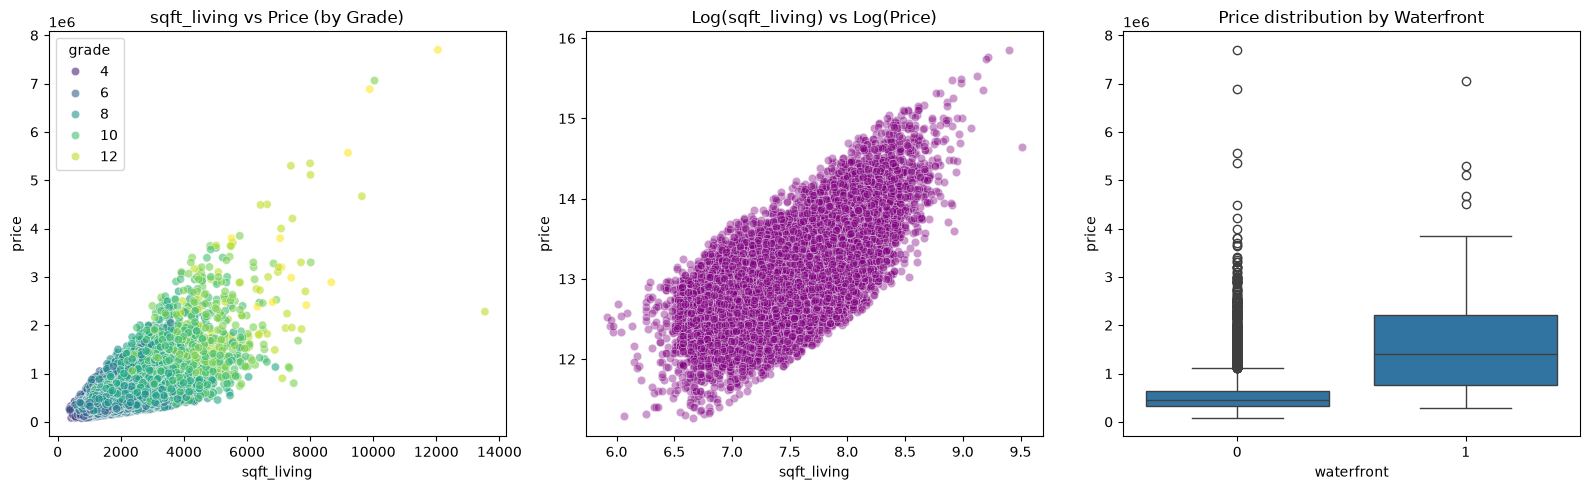

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data= df, x="sqft_living", y="price", hue="grade", palette="viridis", alpha=0.6, ax=axes[0])
axes[0].set_title("sqft_living vs Price (by Grade)")

sns.scatterplot(x=np.log(df["sqft_living"]), y=np.log(df["price"]), alpha=0.4, color="purple", ax=axes[1])
axes[1].set_title("Log(sqft_living) vs Log(Price)")

sns.boxplot(data=df, x="waterfront", y="price", ax=axes[2])
axes[2].set_title("Price distribution by Waterfront")

plt.tight_layout()
plt.show()

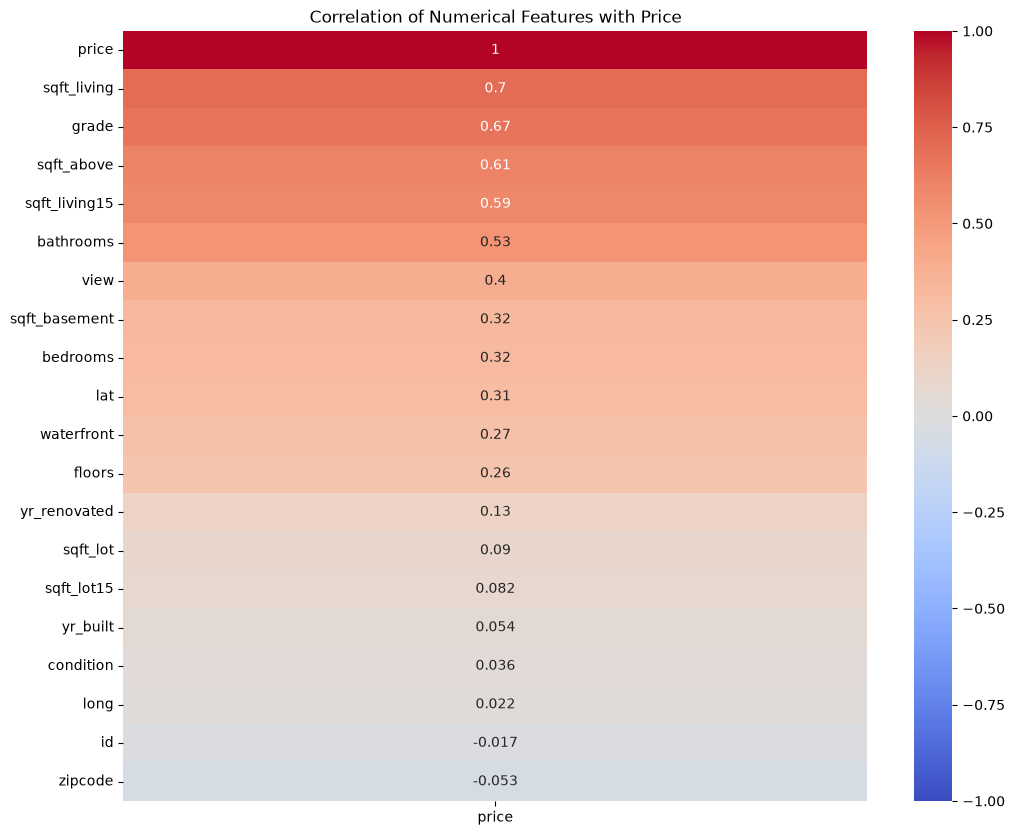

Rows where sqft_living != sqft_above + sqft_basement: 0


In [17]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[["price"]].sort_values(by="price", ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Numerical Features with Price")
plt.show()

mismatches = (df['sqft_living'] != (df['sqft_above'] + df['sqft_basement'])).sum()
print(f"Rows where sqft_living != sqft_above + sqft_basement: {mismatches}")

In [18]:
skew_values = df.skew(numeric_only=True)
right_skewed_cols = skew_values[skew_values > 1.0].index.tolist()
print("Columns to log-transform:", right_skewed_cols)

Columns to log-transform: ['price', 'sqft_living', 'sqft_lot', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_renovated', 'sqft_living15', 'sqft_lot15']


In [19]:
df_model  = df.copy()

In [20]:
df_model.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [21]:
df_model["date"] = pd.to_datetime(df_model["date"])
df_model["sale_year"] = df_model["date"].dt.year
df_model["sale_month"] = df_model["date"].dt.month

df_model["house_age"] = df_model["sale_year"] - df_model["yr_built"]

df_model["is_renovated"] = (df_model["yr_renovated"] > 0).astype(int)
df_model["has_basement"] = (df_model["sqft_basement"] > 0).astype(int)

df_model["log_price"] = np.log(df["price"])
df_model = df_model.drop(columns=["price"])

skewed_col = ["sqft_living", "sqft_lot", "sqft_above", "sqft_living15", "sqft_lot15", "sqft_basement"]
for col in skewed_col:
    df_model[f"log_{col}"] = np.log1p(df[col])

df_model["year_since_renov"] = np.where(
    df_model["is_renovated"] == 1,
    df_model["sale_year"] - df_model["yr_renovated"],
    0
)

df_model["living_to_lot_ratio"] = round(df["sqft_living"]/df["sqft_lot"], 6)
df_model["sqft_living_diff_from_neighbors"] = df["sqft_living"] - df["sqft_living15"]

df_model['zipcode'] = df_model['zipcode'].astype(str)

df_model = pd.get_dummies(df_model, columns=["zipcode"], drop_first=True, dtype=int)

df_model = df_model.drop(columns=["id", "date", "yr_built", "yr_renovated"])

df_model.head(10)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,0,0,0,0,0,0,1,0,0,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,...,0,0,0,0,0,0,0,0,0,0
2,2,1.00,770,10000,1.0,0,0,3,6,770,...,0,0,0,0,0,0,0,0,0,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,...,0,0,0,0,0,0,0,0,0,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,0,0,0,0,0,0,0,0,0,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,...,0,0,0,0,0,0,0,0,0,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,...,0,0,0,0,0,0,0,0,0,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,...,0,0,0,0,0,0,0,0,1,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,...,1,0,0,0,0,0,0,0,0,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df_model.to_csv("D:/HousePricing/data/processed_kc_house_data.csv", index=False)